In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/data.csv", sep=";")

# Keep only Graduate and Dropout
df = df[df["Target"].isin(["Dropout", "Graduate"])].copy()

# Create binary target
df["academic_risk"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

# Remove original target
df.drop(columns=["Target"], inplace=True)

# Remove second-semester leakage
second_sem_columns = [
    col for col in df.columns
    if "2nd sem" in col
]

df.drop(columns=second_sem_columns, inplace=True)

print(df.shape)

(3630, 31)


In [3]:
X = df.drop(columns=["academic_risk"])
y = df["academic_risk"]

print("X:", X.shape)
print("y:", y.shape)

X: (3630, 30)
y: (3630,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2904, 30)
Testing: (726, 30)


In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training:", X_train_processed.shape)
print("Processed testing:", X_test_processed.shape)

Processed training: (2904, 30)
Processed testing: (726, 30)


In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

print("Model training completed!")

Model training completed!


In [8]:
y_pred = model.predict(X_test_processed)

y_prob = model.predict_proba(X_test_processed)[:, 1]

In [9]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not At Risk", "At Risk"]
))

              precision    recall  f1-score   support

 Not At Risk       0.91      0.92      0.91       442
     At Risk       0.87      0.86      0.87       284

    accuracy                           0.90       726
   macro avg       0.89      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.8953
Precision: 0.8714
Recall   : 0.8592
F1 Score : 0.8652
ROC-AUC  : 0.9463


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[406  36]
 [ 40 244]]


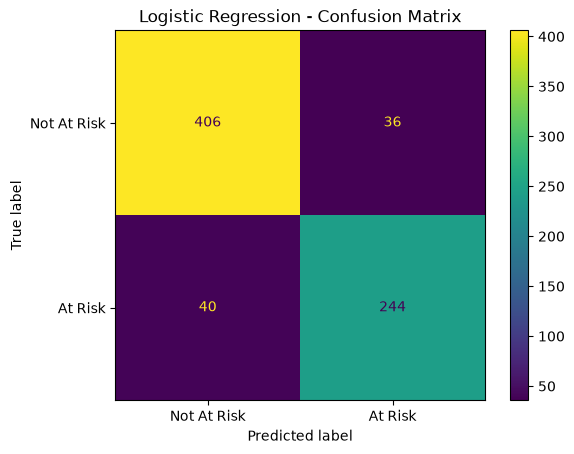

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not At Risk", "At Risk"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

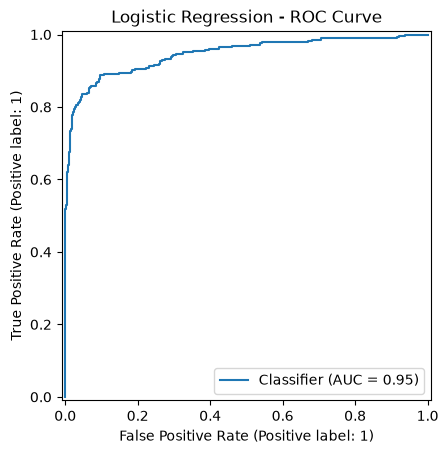

In [13]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [16]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

In [17]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.8898
Precision: 0.8566
Recall   : 0.8627
F1 Score : 0.8596
ROC-AUC  : 0.9463


In [20]:
import xgboost

print(xgboost.__version__)
from xgboost import XGBClassifier

3.4.1


In [21]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [22]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

In [23]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

XGBoost Results
----------------
Accuracy : 0.8939
Precision: 0.8632
Recall   : 0.8662
F1 Score : 0.8647
ROC-AUC  : 0.9553


In [24]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [25]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully!")

Preprocessor saved successfully!
